In [ ]:
## Objetivo do Projeto

# Description : e-commerce transactions
# Evaluation:  area under the ROC curve. Queremos reduzir os Falsos Negativos

## Importar as Bibliotecas

In [2]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
# Remove warnings
import warnings
warnings.filterwarnings('ignore')

## Carregar e ajustar os Datasets

In [2]:
treino_id = pd.read_csv('dados/train_identity.csv')
treino_transacoes = pd.read_csv('dados/train_transaction.csv')
teste_id = pd.read_csv('dados/test_identity.csv')
teste_transacoes = pd.read_csv('dados/test_transaction.csv')

In [3]:
teste_id.columns = [x.replace('-','_') for x in teste_id.columns]

In [4]:
# Train
train = pd.merge(treino_transacoes, treino_id, on='TransactionID', how='left')
train['treino'] = True
del treino_id, treino_transacoes
# Test
test = pd.merge(teste_transacoes, teste_id, on='TransactionID', how='left')
test['treino'] = False
test['isFraud'] = None
del teste_id, teste_transacoes
# All Data
all_data = pd.concat([train, test])
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1097231 entries, 0 to 506690
Columns: 435 entries, TransactionID to treino
dtypes: bool(1), float64(399), int64(3), object(32)
memory usage: 3.6+ GB


In [5]:
del train, test
gc.collect()

0

## Data Cleaning/Preparation

### Checking Missing Values

In [6]:
all_data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,treino
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0

#### Dropping Missing Values

In [7]:
all_data.isnull().sum().sort_values(ascending=False) / len(all_data)

id_24             0.991354
id_25             0.990730
id_26             0.990695
id_07             0.990691
id_08             0.990691
                    ...   
card1             0.000000
ProductCD         0.000000
TransactionAmt    0.000000
TransactionDT     0.000000
treino            0.000000
Length: 435, dtype: float64

In [7]:
drop_null_cols = [col for col in all_data.columns if all_data[col].isnull().sum() / all_data.shape[0] >= 0.28 and col != 'isFraud']

In [8]:
all_data.drop(drop_null_cols, axis=1, inplace=True)

#### Analyzing Numeric Variables

In [9]:
all_data.select_dtypes(exclude=(['O','bool'])).describe()

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
count,1.097231e+06,1.097231e+06,1.097231e+06,1.097231e+06,1.079644e+06,1.092664e+06,1.088425e+06,965916.000000,965916.000000,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.092483e+06,1.097228e+06,1.089931e+06,851458.000000,1.008664e+06,996049.000000,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06
mean,3.575333e+06,1.640384e+07,1.348879e+02,9.925744e+03,3.630998e+02,1.533556e+02,1.996868e+02,291.241913,86.765369,1.224565e+01,1.316624e+01,1.569227e-02,3.304229e+00,5.290377e+00,8.047716e+00,2.308044e+00,3.643492e+00,4.541059e+00,3.656317e+00,8.968402e+00,3.417374e+00,3.036952e+01,7.274049e+00,1.007141e+02,157.700888,1.415345e+02,185.152096,5.646614e-01,5.997874e-01,9.996698e-01,1.314645e-01,1.326979e-01,1.956396e-01,1.972349e-01,8.384751e-01,8.662927e-01,1.885285e-01,1.921286e-01,1.040034e+00,1.0

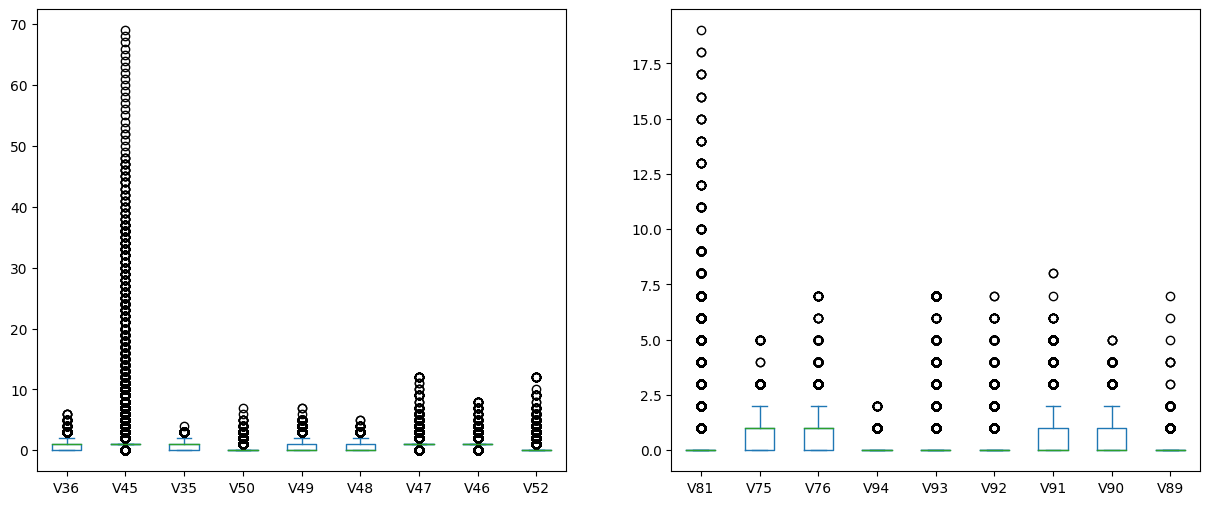

In [10]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))
all_data[['V36', 'V45', 'V35', 'V50', 'V49', 'V48', 'V47', 'V46', 'V52']].plot.box(ax=ax1)
all_data[['V81', 'V75', 'V76', 'V94', 'V93', 'V92', 'V91', 'V90', 'V89']].plot.box(ax=ax2)
plt.show()

#### Analyzing Categorical Variables

In [11]:
all_data['P_emaildomain'].value_counts(dropna=False)[:10]

P_emaildomain
gmail.com        435803
yahoo.com        182784
NaN              163648
hotmail.com       85649
anonymous.com     71062
aol.com           52337
comcast.net       14474
icloud.com        12316
outlook.com        9934
att.net            7647
Name: count, dtype: int64

In [12]:
all_data['card6'].value_counts(dropna=False, normalize=True)

card6
debit              0.751855
credit             0.243930
NaN                0.004172
debit or credit    0.000027
charge card        0.000015
Name: proportion, dtype: float64

In [13]:
all_data['card4'].value_counts(dropna=False, normalize=True)

card4
visa                0.655877
mastercard          0.316602
american express    0.014590
discover            0.008680
NaN                 0.004250
Name: proportion, dtype: float64

#### Impute Missing Data

In [14]:
# Numerical Variables

for col in all_data.select_dtypes(exclude=['O', 'bool']):
    all_data[col] = all_data[col].fillna(all_data[col].median())

In [15]:
# Categorical Variables
# P_emaildomain
all_data.loc[all_data['P_emaildomain'].isin(['gmail.com', 'gmail']),'P_emaildomain'] = 'Google'

all_data.loc[all_data['P_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                         'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                         'yahoo.es']), 'P_emaildomain'] = 'Yahoo'

all_data.loc[all_data['P_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                         'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                         'outlook.es', 'live.com', 'live.fr',
                                         'hotmail.fr']), 'P_emaildomain'] = 'Microsoft'

all_data.loc[all_data.P_emaildomain.isin(all_data.P_emaildomain.value_counts()[all_data.P_emaildomain.value_counts() <= 8000 ].index), 'P_emaildomain'] = "Others"

all_data.P_emaildomain.fillna("NoInf", inplace=True)

# card6
all_data.card6.fillna("NoInf", inplace=True)

# card4
all_data.card4.fillna("NoInf", inplace=True)

In [16]:
all_data.isnull().sum().sort_values(ascending=False)

isFraud    506691
V119            0
V109            0
V110            0
V111            0
            ...  
V50             0
V51             0
V52             0
V53             0
treino          0
Length: 202, dtype: int64

### Checking Constant Variables

#### Verificando se há Variáveis com Pouca Variancia

In [17]:
big_top_value_cols = [col for col in all_data.columns if all_data[col].value_counts(normalize=True).values[0] >= 0.90 and col != 'isFraud']
big_top_value_cols[:5]

['addr2', 'C3', 'V14', 'V23', 'V24']

#### Removendo as Variáveis

In [18]:
all_data.drop(big_top_value_cols, axis=1, inplace=True)

## Exploratory Data Analysis for ML

In [19]:
all_data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317,treino
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,True
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,10.0,4.0,50.0,1758.0,925.0,354.0,135.0,1.0,28.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,38.0,0.0,0.0,0.0,50.0,1758.0,925.0,354.0,135.0,0.0,0.0,0.0,1404.0,True
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True


In [20]:
train = all_data[all_data['treino'] == True].copy()
test = all_data[all_data['treino'] == False].copy()

train.drop('treino', axis=1, inplace=True)
test.drop('treino', axis=1, inplace=True)

In [21]:
del all_data
gc.collect()

25

### Variável Target

In [22]:
train['isFraud'] = train['isFraud'].astype(int)

In [26]:
total = len(train)
normal = len(train[train['isFraud'] == 0])
fraud = len(train[train['isFraud'] == 1])
percent = (fraud / total) * 100

print(f'Total de Transações: {total}')
print(f'Percentual de Transações normais: {normal/total * 100:.2f}')
print(f'Percentual de Fraudes: {percent:.2f}%')

Total de Transações: 590540
Percentual de Transações normais: 96.50
Percentual de Fraudes: 3.50%


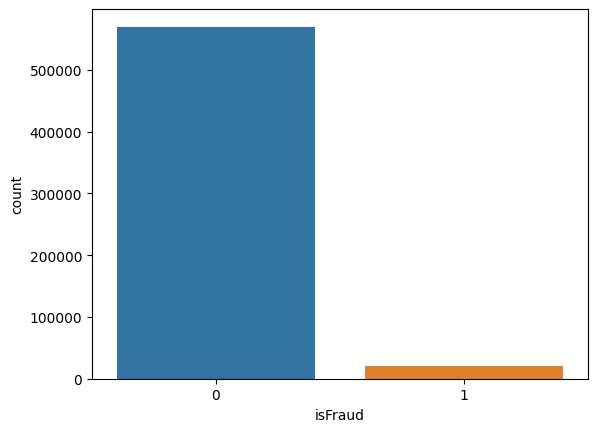

In [25]:
sns.countplot(x=train['isFraud'])
plt.show()

In [27]:
# Most correlated values with isFraud
corr = train.corr(numeric_only=True)
corr[['isFraud']].sort_values(by='isFraud', ascending=False)

,isFraud
isFraud,1.000000
V52,0.195492
V51,0.182007
V40,0.174672
V79,0.167299
...,...
V91,-0.098592
V70,-0.099106
V69,-0.102396
V90,-0.102635


### Variável TransactionDT

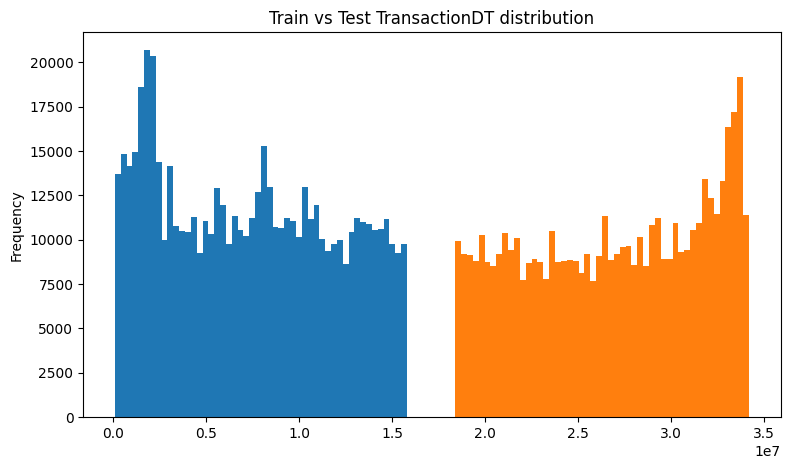

In [28]:
plt.figure(figsize=(9,5))
color_pal = [x['color'] for x in plt.rcParams['axes.prop_cycle']]
plt.title('Train vs Test TransactionDT distribution')
train['TransactionDT'].plot(kind='hist',label='train',bins=50)
test['TransactionDT'].plot(kind='hist',label='test',bins=50, color=color_pal[1])
plt.show()

The TransactionDT feature is a timedelta from a given reference datetime (not an actual timestamp). One early discovery about the data is that the train and test appear to be split by time. There is a slight gap inbetween, but otherwise the training set is from an earlier period of time and test is from a later period of time. This will impact which cross validation techniques should be used.

### Variável TransactionAmt

#### Média dos valores por Transações (Normal/Fraud)

In [29]:
# Transações Normais
train[train['isFraud'] == 0]['TransactionAmt'].describe()

count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [30]:
# Transações Fraudulentas
train[train['isFraud'] == 1]['TransactionAmt'].describe()

count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64

#### Distribuição dos Valores

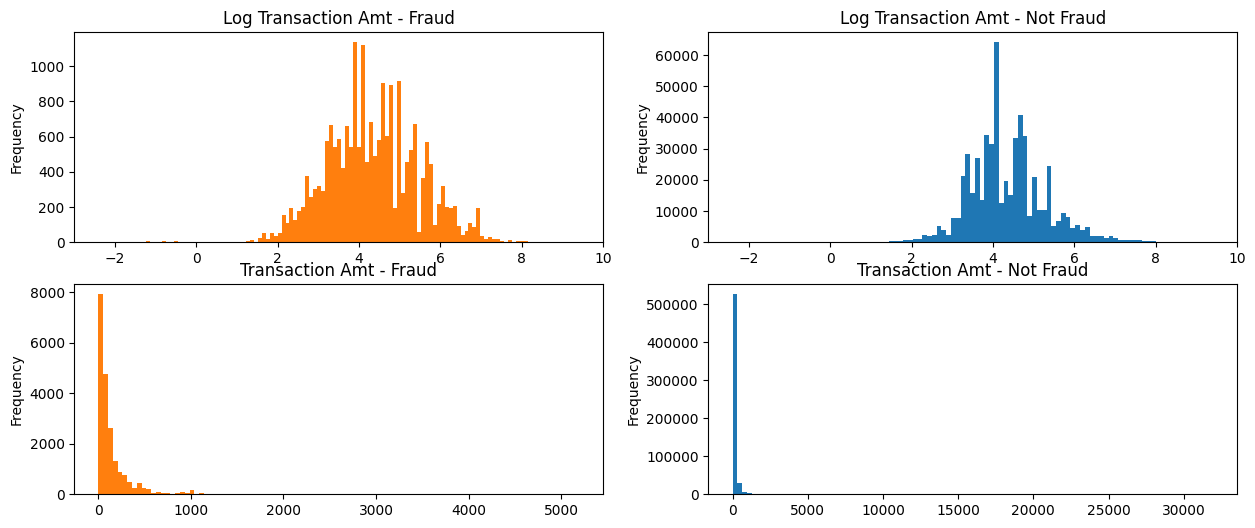

In [31]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 6))

train[train['isFraud'] == 1]['TransactionAmt'].apply(np.log).plot(kind='hist',bins=100,title='Log Transaction Amt - Fraud',color=color_pal[1],xlim=(-3, 10),ax= ax1)
train[train['isFraud'] == 0]['TransactionAmt'].apply(np.log).plot(kind='hist',bins=100,title='Log Transaction Amt - Not Fraud',xlim=(-3, 10),ax=ax2)
train[train['isFraud'] == 1]['TransactionAmt'].plot(kind='hist',bins=100,title='Transaction Amt - Fraud',color=color_pal[1],ax= ax3)
train[train['isFraud'] == 0]['TransactionAmt'].plot(kind='hist',bins=100,title='Transaction Amt - Not Fraud',ax=ax4)
plt.show()

### Variáveis Categóricas

In [32]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,10.0,4.0,50.0,1758.0,925.0,354.0,135.0,1.0,28.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,38.0,0.0,0.0,0.0,50.0,1758.0,925.0,354.0,135.0,0.0,0.0,0.0,1404.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
cat_vars = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'P_emaildomain']

In [34]:
train[cat_vars].describe()

,card1,card2,card3,card5,addr1
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,9898.734658,362.531959,153.186458,199.471611,291.653527
std,4901.170153,156.595356,11.322604,41.157610,95.949345
min,1000.000000,100.000000,100.000000,100.000000,100.000000
25%,6019.000000,215.000000,150.000000,166.000000,205.000000
50%,9678.000000,361.000000,150.000000,226.000000,299.000000
75%,14184.000000,512.000000,150.000000,226.000000,327.000000
max,18396.000000,600.000000,231.000000,237.000000,540.000000


#### Card Cols (Numerics)

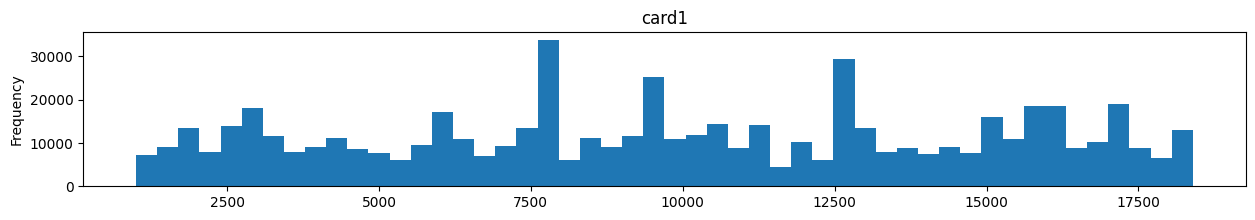

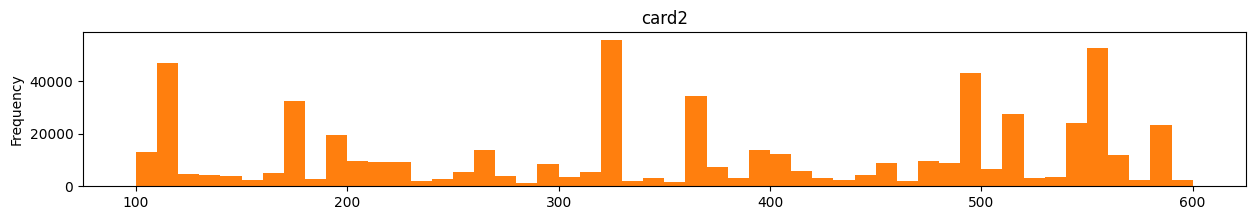

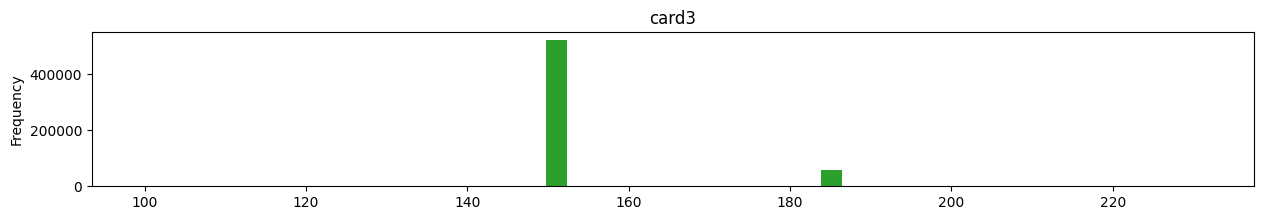

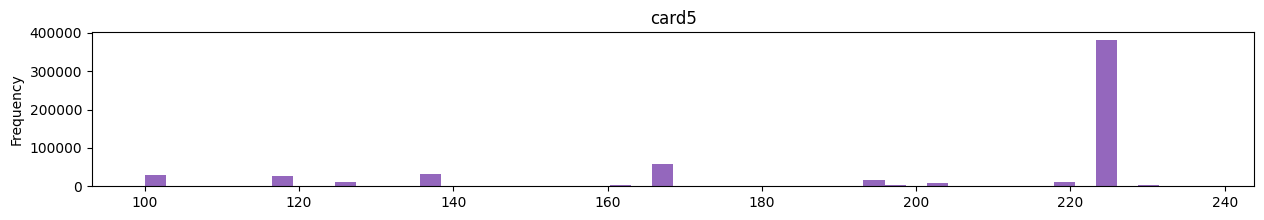

In [35]:
card_cols = [c for c in train.columns if 'card' in c]
color_idx = 0
for c in card_cols:
    if train[c].dtype in ['float64','int64']:
        train[c].plot(kind='hist',title=c,bins=50,figsize=(15, 2),color=color_pal[color_idx])
    color_idx += 1
    plt.show()

In [36]:
train[cat_vars].describe(include='O')

,ProductCD,card4,card6,P_emaildomain
count,590540,590540,590540,590540
unique,5,5,5,9
top,W,visa,debit,Google
freq,439670,384767,439938,228851


#### Variável ProductCD

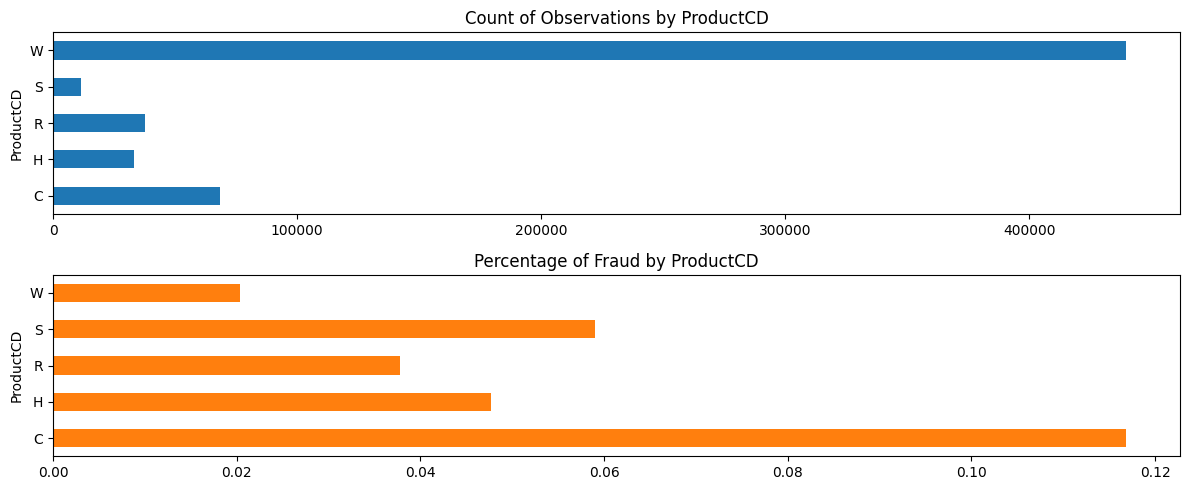

In [37]:
fig, ((ax1), (ax2)) = plt.subplots(2, 1, figsize=(12, 5))
train.groupby('ProductCD')['TransactionID'].count().sort_index().plot(kind='barh',title='Count of Observations by ProductCD',ax=ax1)
train.groupby('ProductCD')['isFraud'].mean().sort_index().plot(kind='barh',title='Percentage of Fraud by ProductCD',ax=ax2, color=color_pal[1])
plt.tight_layout()
plt.show()

#### Big Insight

**Insight:**
- Produto W apresenta maior número de transações e menor número de fraudes.
- Produto S apresenta menor número de transações com bastante fraude.
- Produto C apresenta o maior número de transações fraudulentas.

### Variáveis Numéricas

In [38]:
train.iloc[:,13:].describe()

,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215,94.153422,106.534282,109.695071,146.580423,0.616429,0.650801,0.106582,0.107556,0.116773,0.117926,0.840026,0.867443,0.112978,0.115250,0.337879,0.354079,0.122628,0.124071,0.113857,0.121228,0.673470,0.699600,0.118558,0.126459,0.111449,0.120603,0.273538,0.283925,0.117608,0.121772,0.130421,0.632733,0.669594,0.111561,0.115161,0.116883,0.123929,0.852007,0.884853,0.113674,0.123309,0.339259,0.354669,0.122278,0.126178,0.121707,0.132284,0.613086,0.649831,0.116202,0.122219,0.129641,0.868072,0.899787,0.116437,0.127172,0.341186,0.356977,0.127626,0.131437,0.116321,1.037467,3.003592,1.718019,0.894510,0.273358,129.910305,336.432577,203.985518,92.116843,31.116748,1.123038,1.967042,0.817564,0.991134,1.167636,0.358572,0.183954,0.235468,1.659798,1.239911,2.313816,0.251756,0.283134,0.264202,139.745873,408.674070,230.408498,118.193256,39.173114,21.305592,43.226087,26.749372,247.601710
std,133.569018,154.668899,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262,157.546457,169.905435,174.461383,191.191196,0.498822,0.514556,0.312968,0.322659,0.343124,0.349943,0.401896,0.431856,0.319436,0.338382,0.494019,0.534993,0.335418,0.347035,0.321184,0.336966,0.482509,0.493552,0.389169,0.434779,0.331118,0.374026,0.462981,0.492470,0.324646,0.349858,0.379996,0.497787,0.514694,0.328368,0.350566,0.356555,0.392920,0.411139,0.453320,0.334177,0.381720,0.496704,0.534992,0.342980,0.366196,0.345531,0.370271,0.501204,0.517454,0.353464,0.381219,0.420326,0.393281,0.435818,0.337034,0.390188,0.496881,0.539156,0.350319,0.374820,0.320630,21.028724,40.228850,27.693112,2.721906,0.946945,2346.329554,4237.547017,3009.462042,315.883618,161.120004,21.021737,27.851498,0.920928,1.557055,3.282425,1.078985,0.430610,0.598687,16.252373,3.775012,39.526068,0.481885,0.623603,0.528234,2348.825854,4391.948740,3021.893722,352.979909,172.126681,95.804974,173.443984,116.734202,3980.002546
min,0.000000,0.

#### C Columns

Because we are provided many numerical columns, we can create a pairplot to plot feature interactions. I know these plots can be hard to read, but it is helpful for gaining intution about potential feature interactions and if certain features have more variance than others.

In [39]:
c_cols = [c for c in train if c[0] == 'C']
train[c_cols].head()

,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
3,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0
4,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


In [40]:
train[c_cols].describe()

,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


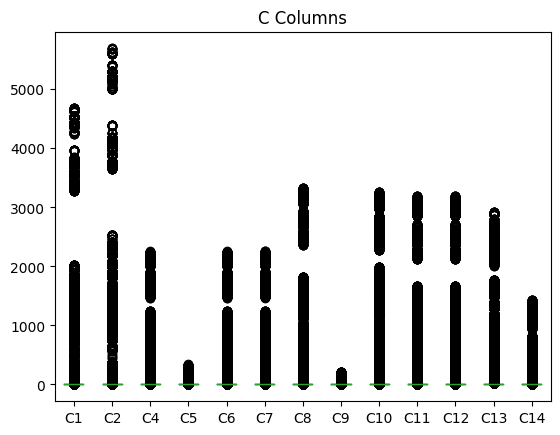

In [41]:
train[c_cols].plot.box()
plt.title('C Columns')
plt.show()

In [42]:
sel_c_cols = ['C1', 'C5', 'C7', 'C9', 'C11', 'C13']

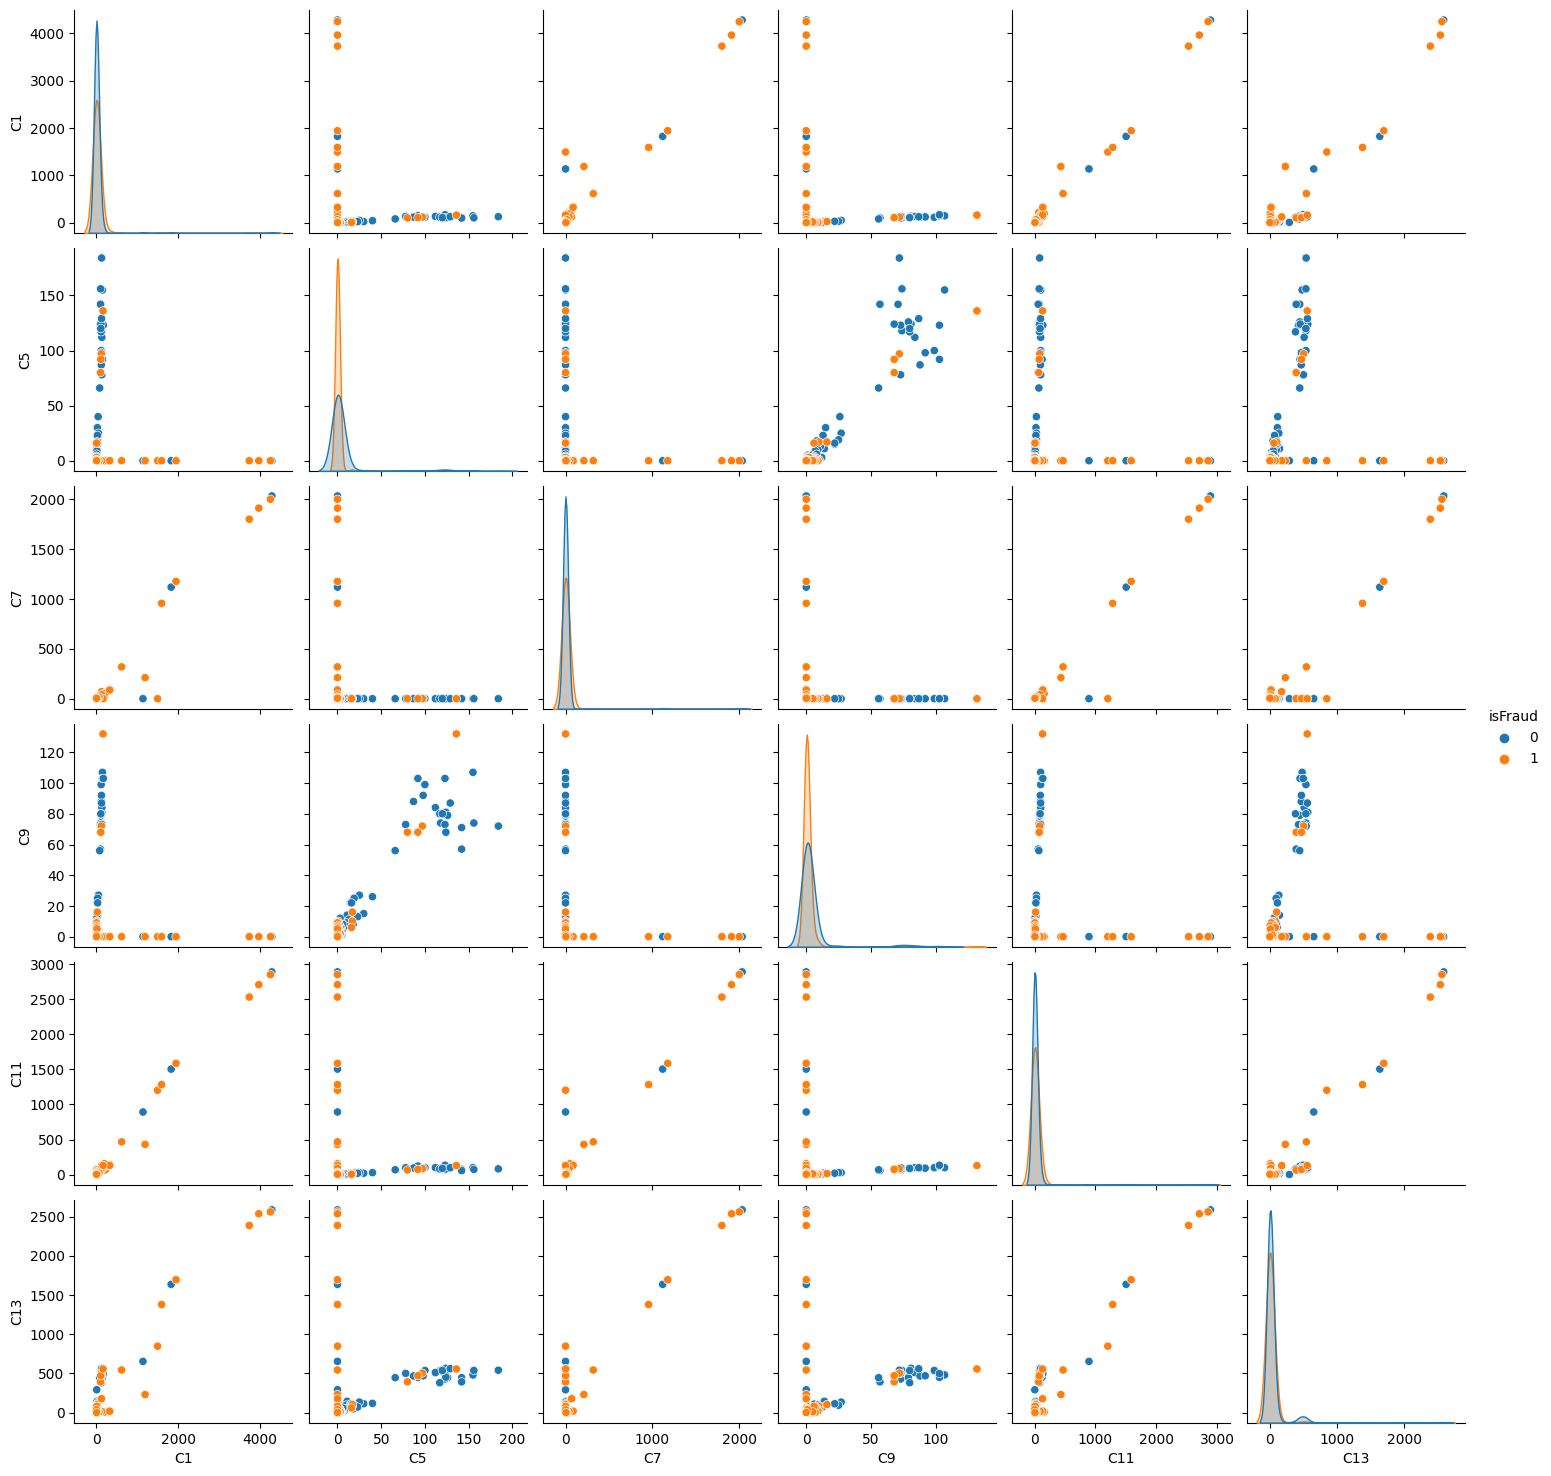

In [43]:
sampled_train = pd.concat([train.loc[train['isFraud'] == 0].sample(500),
          train[train['isFraud'] == 1].sample(500)])

sns.pairplot(sampled_train, 
             hue='isFraud',
            vars=sel_c_cols)
plt.show()

#### D Columns

In [44]:
d_cols = [c for c in train if c[0] == 'D']
train[d_cols].head()

,D1,D4,D10,D15
0,14.0,23.0,13.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,315.0
3,112.0,94.0,84.0,111.0
4,0.0,23.0,13.0,50.0


In [45]:
train[d_cols].describe()

,D1,D4,D10,D15
count,590540.000000,590540.000000,590540.000000,590540.000000
mean,94.153422,106.534282,109.695071,146.580423
std,157.546457,169.905435,174.461383,191.191196
min,0.000000,-122.000000,0.000000,-83.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,3.000000,23.000000,13.000000,50.000000
75%,121.000000,123.000000,150.000000,251.000000
max,640.000000,869.000000,876.000000,879.000000


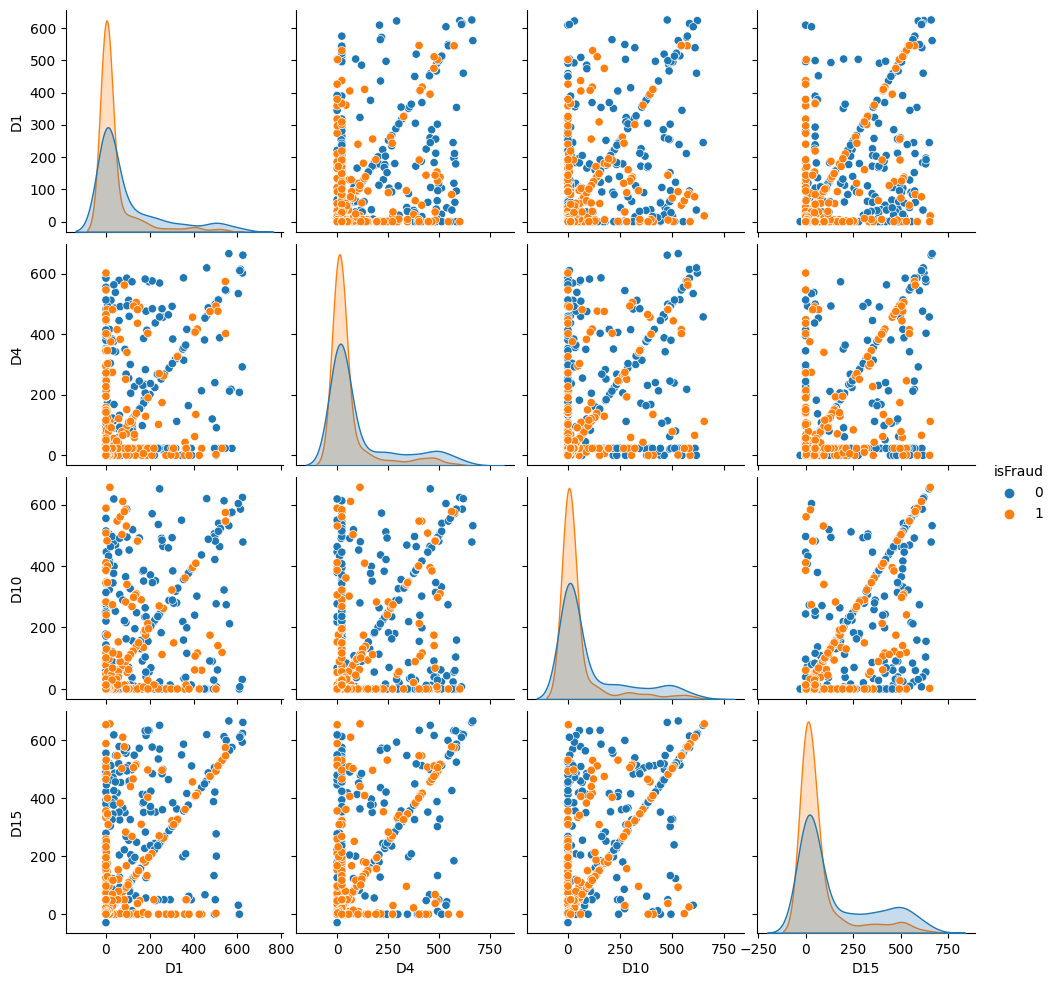

In [46]:
sampled_train = pd.concat([train.loc[train['isFraud'] == 0].sample(500),
          train[train['isFraud'] == 1].sample(500)])

sns.pairplot(sampled_train, 
             hue='isFraud',
            vars=d_cols)
plt.show()

#### V Columns

In [47]:
v_cols = [c for c in train if c[0] == 'V']
train[v_cols].head()

,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,10.0,4.0,50.0,1758.0,925.0,354.0,135.0,1.0,28.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,38.0,0.0,0.0,0.0,50.0,1758.0,925.0,354.0,135.0,0.0,0.0,0.0,1404.0
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
train[v_cols].describe()

,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,0.616429,0.650801,0.106582,0.107556,0.116773,0.117926,0.840026,0.867443,0.112978,0.115250,0.337879,0.354079,0.122628,0.124071,0.113857,0.121228,0.673470,0.699600,0.118558,0.126459,0.111449,0.120603,0.273538,0.283925,0.117608,0.121772,0.130421,0.632733,0.669594,0.111561,0.115161,0.116883,0.123929,0.852007,0.884853,0.113674,0.123309,0.339259,0.354669,0.122278,0.126178,0.121707,0.132284,0.613086,0.649831,0.116202,0.122219,0.129641,0.868072,0.899787,0.116437,0.127172,0.341186,0.356977,0.127626,0.131437,0.116321,1.037467,3.003592,1.718019,0.894510,0.273358,129.910305,336.432577,203.985518,92.116843,31.116748,1.123038,1.967042,0.817564,0.991134,1.167636,0.358572,0.183954,0.235468,1.659798,1.239911,2.313816,0.251756,0.283134,0.264202,139.745873,408.674070,230.408498,118.193256,39.173114,21.305592,43.226087,26.749372,247.601710
std,0.498822,0.514556,0.312968,0.322659,0.343124,0.349943,0.401896,0.431856,0.319436,0.338382,0.494019,0.534993,0.335418,0.347035,0.321184,0.336966,0.482509,0.493552,0.389169,0.434779,0.331118,0.374026,0.462981,0.492470,0.324646,0.349858,0.379996,0.497787,0.514694,0.328368,0.350566,0.356555,0.392920,0.411139,0.453320,0.334177,0.381720,0.496704,0.534992,0.342980,0.366196,0.345531,0.370271,0.501204,0.517454,0.353464,0.381219,0.420326,0.393281,0.435818,0.337034,0.390188,0.496881,0.539156,0.350319,0.374820,0.320630,21.028724,40.228850,27.693112,2.721906,0.946945,2346.329554,4237.547017,3009.462042,315.883618,161.120004,21.021737,27.851498,0.920928,1.557055,3.282425,1.078985,0.430610,0.598687,16.252373,3.775012,39.526068,0.481885,0.623603,0.528234,2348.825854,4391.948740,3021.893722,352.979909,172.126681,95.804974,173.443984,116.734202,3980.002546
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

In [49]:
train['v_mean'] = train[v_cols].mean(axis=1)
test['v_mean'] = test[v_cols].mean(axis=1)

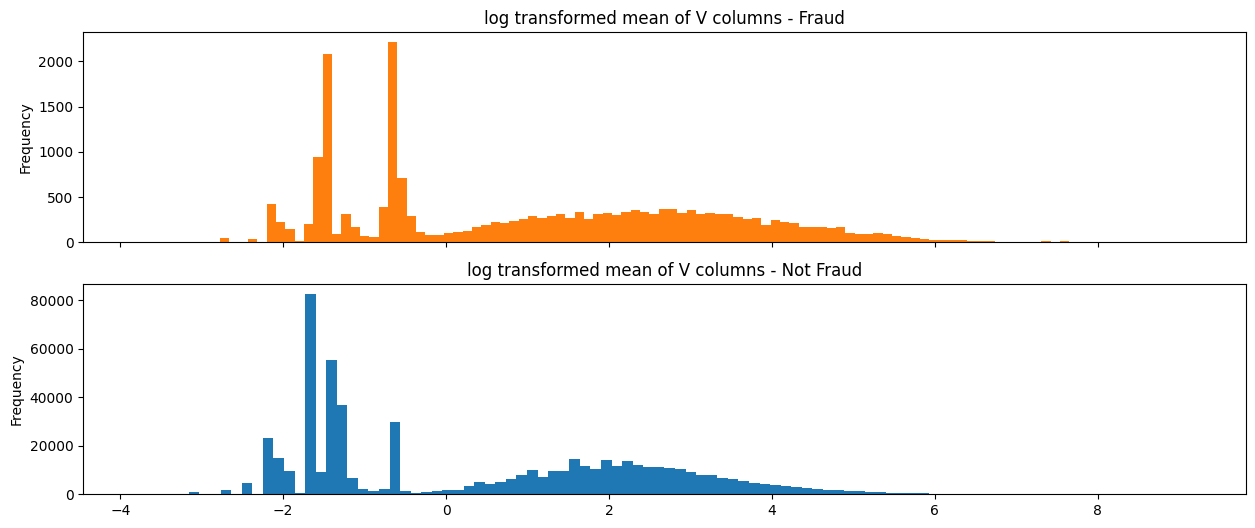

In [50]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 6))
train[train['isFraud'] == 1]['v_mean'].apply(np.log).plot(kind='hist',bins=100,title='log transformed mean of V columns - Fraud',color=color_pal[1], ax=ax1)
train[train['isFraud'] == 0]['v_mean'].apply(np.log).plot(kind='hist',bins=100,title='log transformed mean of V columns - Not Fraud',ax=ax2)
plt.show()

## Feature Engineering

In [51]:
train['cents'] = (train['TransactionAmt'] - np.floor(train['TransactionAmt'])).astype('float32')
test['cents'] = (test['TransactionAmt'] - np.floor(test['TransactionAmt'])).astype('float32')

In [52]:
# LABEL ENCODE
def encode_LE(col,train=train,test=test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')

# COMBINE FEATURES
def encode_CB(col1,col2,df1=train,df2=test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')

card1_addr1 , card1_addr1_P_emaildomain , 

In [53]:
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=train, test_df=test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')

encode_AG(['TransactionAmt'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 

In [ ]:
# New feature - log of transaction amount.
#train['TransactionAmt_Log'] = np.log(train['TransactionAmt'])
#test['TransactionAmt_Log'] = np.log(test['TransactionAmt'])

In [ ]:
#train['v_mean'] = np.log(train['v_mean'])
#test['v_mean'] = np.log(test['v_mean'])

In [55]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317,v_mean,cents,card1_addr1,card1_addr1_P_emaildomain,TransactionAmt_card1_mean,TransactionAmt_card1_std,TransactionAmt_card1_addr1_mean,TransactionAmt_card1_addr1_std,TransactionAmt_card1_addr1_P_emaildomain_mean,TransactionAmt_card1_addr1_P_emaildomain_std
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,4.100000,0.5,13700,8257,316.570343,351.514008,142.000000,152.654022,68.500000,-1.000000
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.0,31872,52521,213.053818,391.543884,236.318405,499.708618,512.468567,996.724609
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.0,37566,66088,104.876938,130.380966,65.733833,54.568237,58.666668,26.507860
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,10.0,4.0,50.0,1758.0,925.0,354.0,135.0,1.0,28.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,38.0,0.0,0.0,0.0,50.0,1758.0,925.0,354.0,135.0,0.0,0.0,0.0,1404.0,89.288889,0.0,27964,42474,120.958702,196.463486,112.923775,211.492188,74.112679,57.115608
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.233333,0.0,37070,65054,99.811668,69.829735,50.000000,-1.000000,50.000000,-1.000000


In [56]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain']
train[cat_cols].describe()

,ProductCD,card4,card6,P_emaildomain
count,590540,590540,590540,590540
unique,5,5,5,9
top,W,visa,debit,Google
freq,439670,384767,439938,228851


In [57]:
train = pd.get_dummies(train, drop_first=True, dtype=float)

In [59]:
test = pd.get_dummies(test, drop_first=True, dtype=float)

In [60]:
display(train.head())
display(test.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317,v_mean,cents,card1_addr1,card1_addr1_P_emaildomain,TransactionAmt_card1_mean,TransactionAmt_card1_std,TransactionAmt_card1_addr1_mean,TransactionAmt_card1_addr1_std,TransactionAmt_card1_addr1_P_emaildomain_mean,TransactionAmt_card1_addr1_P_emaildomain_std,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_charge card,card6_credit,card6_debit,card6_debit or credit,P_emaildomain_Microsoft,P_emaildomain_NoInf,P_emaildomain_Others,P_emaildomain_Yahoo,P_emaildomain_anonymous.com,P_emaildomain_aol.com,P_emaildomain_comcast.net,P_emaildomain_icloud.com
0,2987000,0,86400,68.5,13926,361.0,150.0,142.0,315.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,4.100000,0.5,13700,8257,316.570343,351.514008,142.000000,152.654022,68.500000,-1.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,2755,404.0,150.0,102.0,325.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.0,31872,52521,213.053818,391.543884,236.318405,499.708618,512.468567,996.724609,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,4663,490.0,150.0,166.0,330.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.0,37566,66088,104.876938,130.380966,65.733833,54.568237,58.666668,26.507860,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,18132,567.0,150.0,117.0,476.0,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,10.0,4.0,50.0,1758.0,925.0,354.0,135.0,1.0,28.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,38.0,0.0,0.0,0.0,50.0,1758.0,925.0,354.0,135.0,0.0,0.0,0.0,1404.0,89.288889,0.0,27964,42474,120.958702,196.463486,112.923775,211.492188,74.112679,57.115608,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,4497,514.0,150.0,102.0,420.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317,v_mean,cents,card1_addr1,card1_addr1_P_emaildomain,TransactionAmt_card1_mean,TransactionAmt_card1_std,TransactionAmt_card1_addr1_mean,TransactionAmt_card1_addr1_std,TransactionAmt_card1_addr1_P_emaildomain_mean,TransactionAmt_card1_addr1_P_emaildomain_std,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_charge card,card6_credit,card6_debit,P_emaildomain_Microsoft,P_emaildomain_NoInf,P_emaildomain_Others,P_emaildomain_Yahoo,P_emaildomain_anonymous.com,P_emaildomain_aol.com,P_emaildomain_comcast.net,P_emaildomain_icloud.com
0,3663549,18403224,31.95,10409,111.0,150.0,226.0,170.0,6.0,6.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,398.0,418.0,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.000000,47.950001,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,47.950001,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.0,2.275556,0.95,1479,10951,111.438995,127.021957,113.344917,136.973511,85.400154,95.048073,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3663550,18403263,49.00,4272,111.0,150.0,226.0,299.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,634.0,231.0,634.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,4.0,1.0,0.000000,280.000000,77.000000,280.000000,77.000000,0.0,1.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,280.000000,77.000000,280.000000,77.000000,0.000000,0.000000,0.000000,0.0,16.200000,0.00,36485,63729,154.212906,315.255707,157.276566,328.193390,103.619629,102.606659,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3663551,18403310,171.00,4476,574.0,150.0,226.0,472.0,2.0,2.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,97.0,136.0,97.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,3.0,0.0,0.000000,968.000000,0.000000,705.000000,0.000000,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.000000,1321.000000,0.000000,1058.000000,0.000000,0.000000,0.000000,0.000000,0.0,45.344444,0.00,37028,64952,137.671448,134.993744,137.671448,134.993744,159.897003,84.730461,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3663552,18403310,284.95,10989,360.0,150.0,166.0,205.0,5.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,242.0,242.0,242.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,282.540009,282.540009,282.540009,0.0,9.751334,0.95,3552,61388,89.571312,130.253830,93.607742,82.316505,99.594070,86.554283,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0

In [61]:
train.shape, test.shape

((590540, 146), (506691, 144))

In [63]:
print("Variables in train but not in test: ", set(train.columns).difference(set(test.columns)))

Variables not in test but in train :  {'isFraud', 'card6_debit or credit'}


In [64]:
train.drop('card6_debit or credit', axis=1, inplace=True)

In [65]:
train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
display(train.head())
display(test.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317,v_mean,cents,card1_addr1,card1_addr1_P_emaildomain,TransactionAmt_card1_mean,TransactionAmt_card1_std,TransactionAmt_card1_addr1_mean,TransactionAmt_card1_addr1_std,TransactionAmt_card1_addr1_P_emaildomain_mean,TransactionAmt_card1_addr1_P_emaildomain_std,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_charge card,card6_credit,card6_debit,P_emaildomain_Microsoft,P_emaildomain_NoInf,P_emaildomain_Others,P_emaildomain_Yahoo,P_emaildomain_anonymous.com,P_emaildomain_aol.com,P_emaildomain_comcast.net,P_emaildomain_icloud.com
0,2987000,0,86400,68.5,13926,361.0,150.0,142.0,315.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,4.100000,0.5,13700,8257,316.57034,351.514000,142.000000,152.654020,68.500000,-1.00000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,2755,404.0,150.0,102.0,325.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.0,31872,52521,213.05382,391.543880,236.318400,499.708620,512.468570,996.72460,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,4663,490.0,150.0,166.0,330.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000,0.0,37566,66088,104.87694,130.380970,65.733830,54.568237,58.666668,26.50786,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,18132,567.0,150.0,117.0,476.0,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,10.0,4.0,50.0,1758.0,925.0,354.0,135.0,1.0,28.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,38.0,0.0,0.0,0.0,50.0,1758.0,925.0,354.0,135.0,0.0,0.0,0.0,1404.0,89.288889,0.0,27964,42474,120.95870,196.463490,112.923775,211.492190,74.112680,57.11561,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,4497,514.0,150.0,102.0,420.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V39,V40,V42,V43,V48,V49,V50,V51,V52,V53,V54,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V79,V80,V81,V82,V83,V84,V85,V90,V91,V92,V93,V94,V95,V96,V97,V99,V100,V126,V127,V128,V130,V131,V279,V280,V282,V283,V285,V287,V288,V289,V291,V292,V294,V302,V303,V304,V306,V307,V308,V310,V312,V313,V314,V315,V317,v_mean,cents,card1_addr1,card1_addr1_P_emaildomain,TransactionAmt_card1_mean,TransactionAmt_card1_std,TransactionAmt_card1_addr1_mean,TransactionAmt_card1_addr1_std,TransactionAmt_card1_addr1_P_emaildomain_mean,TransactionAmt_card1_addr1_P_emaildomain_std,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_charge card,card6_credit,card6_debit,P_emaildomain_Microsoft,P_emaildomain_NoInf,P_emaildomain_Others,P_emaildomain_Yahoo,P_emaildomain_anonymous.com,P_emaildomain_aol.com,P_emaildomain_comcast.net,P_emaildomain_icloud.com
0,3663549,18403224,31.95,10409,111.0,150.0,226.0,170.0,6.0,6.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,398.0,418.0,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.000000,47.950001,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,47.950001,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.0,2.275556,0.95,1479,10951,111.438995,127.02196,113.344920,136.973510,85.400154,95.04807,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3663550,18403263,49.00,4272,111.0,150.0,226.0,299.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,634.0,231.0,634.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,4.0,1.0,0.000000,280.000000,77.000000,280.000000,77.000000,0.0,1.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,280.000000,77.000000,280.000000,77.000000,0.000000,0.000000,0.000000,0.0,16.200000,0.00,36485,63729,154.212900,315.25570,157.276570,328.193400,103.619630,102.60666,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,3663551,18403310,171.00,4476,574.0,150.0,226.0,472.0,2.0,2.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,97.0,136.0,97.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,3.0,0.0,0.000000,968.000000,0.000000,705.000000,0.000000,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.000000,1321.000000,0.000000,1058.000000,0.000000,0.000000,0.000000,0.000000,0.0,45.344444,0.00,37028,64952,137.671450,134.99374,137.671450,134.993740,159.897000,84.73046,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3663552,18403310,284.95,10989,360.0,150.0,166.0,205.0,5.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,242.0,242.0,242.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,282.540009,282.540009,282.540009,0.0,9.751334,0.95,3552,61388,89.571310,130.25383,93.607740,82.316505,99.594070,86.55428,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0

In [7]:
train.isFraud.value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [6]:
train.isFraud.value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

## Cross Validation

In [4]:
X = train.sort_values('TransactionDT').drop(['isFraud', 'TransactionDT', 'TransactionID'], axis=1)
y = train.sort_values('TransactionDT')['isFraud']

In [5]:
test.drop(['TransactionDT', 'TransactionID'], axis=1, inplace=True)
del train

In [15]:
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, recall_score
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

### TimeSeriesSplit

In [31]:
tscv = TimeSeriesSplit()

all_scores = []
all_recalls = []

for train_index, test_index in tscv.split(X):
#     print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model = RandomForestClassifier(n_jobs=-1)

    model.fit(X_train, y_train)
    y_preds = model.predict(X_test)

    roc_auc = roc_auc_score(y_preds, y_test)
    recall = recall_score(y_test, y_preds)
    
    all_scores.append(roc_auc)
    all_recalls.append(recall)

print('ROC AUC: ', np.mean(all_scores))
print('Recalls: ', np.mean(all_recalls))

ROC AUC: 
[0.9344825554816878, 0.9346697792663047, 0.9147574608470475, 0.9116821800899797, 0.897966889157744]
0.9187117729685527
Recalls: 
[0.234351375869368, 0.31271562345983245, 0.28377645143787306, 0.32772653282691266, 0.3211657344715926]
0.29594714361311575


### Stratfied K-fold

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_scores = []
all_recalls = []

for train_index, test_index in skf.split(X,y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model = RandomForestClassifier(n_jobs=-1)

    model.fit(X_train, y_train)
    y_preds = model.predict(X_test)

    roc_auc = roc_auc_score(y_preds, y_test)
    recall = recall_score(y_test, y_preds)
    
    all_scores.append(roc_auc)
    all_recalls.append(recall)
      
print('ROC AUC: ')
print(all_scores)
print(np.mean(all_scores))
print('Recalls: ')
print(all_recalls)
print(np.mean(all_recalls))

ROC AUC: 
[0.9470391486048747, 0.9538612641699146, 0.943615330271334, 0.9432469938252883, 0.9432851009905738]
0.946209567572397
Recalls: 
[0.5111326234269119, 0.5043562439496612, 0.510041132349383, 0.49503992257440116, 0.4800387127994193]
0.5001217270199554


### K-fold Diferentes Estrategias

In [11]:
def cross_validation(model, X, y, oversampling=False, undersampling=False, borderlinesmote=False, adasyn=False):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    all_scores = []
    all_recalls = []

    if oversampling: print('SMOTE')
    if undersampling: print('RandomUnderSampler')
    if borderlinesmote: print('BorderlineSMOTE')
    if adasyn: print('ADASYN')

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        if oversampling:
            sm = SMOTE(random_state=42)
            X_train, y_train = sm.fit_resample(X_train, y_train)

        if undersampling:
            u_smpl = RandomUnderSampler(random_state = 42)
            X_train, y_train = u_smpl.fit_resample(X_train, y_train)

        if borderlinesmote:
            bsmote = BorderlineSMOTE(random_state = 42)
            X_train, y_train = bsmote.fit_resample(X_train, y_train)

        if adasyn:
            adasyn = ADASYN(random_state = 42)
            X_train, y_train = adasyn.fit_resample(X_train, y_train)
        
        model.fit(X_train, y_train)
        y_preds = model.predict(X_test)

        roc_auc = roc_auc_score(y_preds, y_test)
        recall = recall_score(y_test, y_preds)
    
        all_scores.append(roc_auc)
        all_recalls.append(recall)
        
        #print(f'{i} fold accuracy: {roc_auc}')

    print('Media ROC AUC:', np.mean(all_scores))
    print('Media Recall:', np.mean(all_recalls))
    print()

    return np.mean(all_scores), np.mean(all_recalls)

In [13]:
model = RandomForestClassifier(n_jobs=-1)
mean_scores_rf_over, mean_recall_rf_over = cross_validation(model, X, y, oversampling=True)
mean_scores_rf_under, mean_recall_rf_under = cross_validation(model, X, y, undersampling=True)
mean_scores_rf_border, mean_recall_rf_border = cross_validation(model, X, y, borderlinesmote=True)
mean_scores_rf_adasyn, mean_recall_rf_adasyn = cross_validation(model, X, y, adasyn=True)

SMOTE
Media ROC AUC: 0.9238185041523534
Media Recall: 0.5254991675798548

RandomUnderSampler
Media ROC AUC: 0.5948050141290917
Media Recall: 0.8423330079070744

BorderlineSMOTE
Media ROC AUC: 0.9277730977169192
Media Recall: 0.5094241643995929

ADASYN
Media ROC AUC: 0.9232771009579419
Media Recall: 0.5319804235664005



In [16]:
xgb = XGBClassifier(n_jobs=-1)
mean_scores_xgb_over, mean_recall_xgb_over = cross_validation(xgb, X, y, oversampling=True)
mean_scores_xgb_under, mean_recall_xgb_under = cross_validation(xgb, X, y, undersampling=True)
mean_scores_xgb_border, mean_recall_xgb_border = cross_validation(xgb, X, y, borderlinesmote=True)
mean_scores_xgb_adasyn, mean_recall_xgb_adasyn = cross_validation(xgb, X, y, adasyn=True)

SMOTE
Media ROC AUC: 0.8942287081871394
Media Recall: 0.48195617317041206

RandomUnderSampler
Media ROC AUC: 0.6049867180623425
Media Recall: 0.848800837666235

BorderlineSMOTE
Media ROC AUC: 0.892160154776434
Media Recall: 0.4754343444548903

ADASYN
Media ROC AUC: 0.8902084028254709
Media Recall: 0.46770367123953244



In [17]:
hgb = HistGradientBoostingClassifier()
mean_scores_hgb_over, mean_recall_hgb_over = cross_validation(hgb, X, y, oversampling=True)
mean_scores_hgb_under, mean_recall_hgb_under = cross_validation(hgb, X, y, undersampling=True)
mean_scores_hgb_border, mean_recall_hgb_border = cross_validation(hgb, X, y, borderlinesmote=True)
mean_scores_hgb_adasyn, mean_recall_hgb_adasyn = cross_validation(hgb, X, y, adasyn=True)

SMOTE
Media ROC AUC: 0.8220399807775973
Media Recall: 0.4658413827069648

RandomUnderSampler
Media ROC AUC: 0.5904392228126365
Media Recall: 0.8272259028572899

BorderlineSMOTE
Media ROC AUC: 0.8065437493276079
Media Recall: 0.44166013026189843

ADASYN


KeyboardInterrupt: 

In [ ]:
ada = AdaBoostClassifier()
mean_scores_ada_over, mean_recall_ada_over = cross_validation(ada, X, y, oversampling=True)
mean_scores_ada_under, mean_recall_ada_under = cross_validation(ada, X, y, undersampling=True)
mean_scores_ada_border, mean_recall_ada_border = cross_validation(ada, X, y, borderlinesmote=True)
mean_scores_ada_adasyn, mean_recall_ada_adasyn = cross_validation(ada, X, y, adasyn=True)

In [ ]:
extraT = ExtraTreesClassifier()
mean_scores_extraT_over, mean_recall_extraT_over = cross_validation(extraT, X, y, oversampling=True)
mean_scores_extraT_under, mean_recall_extraT_under = cross_validation(extraT, X, y, undersampling=True)
mean_scores_extraT_border, mean_recall_extraT_border = cross_validation(extraT, X, y, borderlinesmote=True)
mean_scores_extraT_adasyn, mean_recall_extraT_adasyn = cross_validation(extraT, X, y, adasyn=True)

## Modeling

## Model Evaluation